# BioReason-Pro SFT term-prediction assessments

This notebook audits the per-term prediction assessments stored in
`genes/<species>/<gene>/<gene>-sft-predictions.yaml`. Each predicted GO term
carries a `review.assessment` using the de Crecy-Lagard taxonomy (COR / CNN /
LSP / UNC / PLI / NPI / REP), the same scheme used in the 7-gene *E. coli*
replication and in **Table 5** of the manuscript.

The full SFT term-prediction audit contains 184 genes. Table 5 uses the cleaner
HuggingFace `wanglab/protein_catalogue` subset (140 genes, leaf terms); the
BioReason-Pro web-export subset (44 genes) includes many GO ancestor terms and
is reported separately in the text. The cohort membership is enumerated in
`projects/BIOREASON_COMPARISON/benchmark-cohorts.csv` and
`projects/BIOREASON_COMPARISON/benchmark-genes.csv`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import bioreason_stats as bs

ROOT = bs.find_repo_root()
preds = bs.load_prediction_assessments(ROOT)
n_genes = preds[["species", "gene"]].drop_duplicates().shape[0]
print(f"genes with prediction files: {n_genes}")
print(f"total predicted terms:       {len(preds)}")
print("\nsource methods:")
print(preds.source_method.value_counts().to_string())
print("\nsource versions:")
print(preds.source_version.value_counts().to_string())
preds.head()

genes with prediction files: 184
total predicted terms:       11034

source methods:
source_method
BioReason-Pro-SFT    11034

source versions:
source_version
app.bioreason.net/SFT        9742
wanglab/protein_catalogue    1292


,species,gene,source_method,source_version,term_id,term_label,term_type,assessment,confidence_score,path
0,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0003824,catalytic activity,GO_MF,LSP,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml
1,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0016491,oxidoreductase activity,GO_MF,CNN,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml
2,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0016645,acting on the CH-NH group of donors,GO_MF,LSP,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml
3,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0016646,NAD or NADP as acceptor,GO_MF,CNN,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml
4,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0004146,dihydrofolate reductase activity,GO_MF,CNN,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml


## Terms per gene

A genuinely reproducible structural statistic (independent of the manual review state).

In [2]:
per_gene = preds.groupby(["species", "gene"]).size().rename("n_terms")
print(per_gene.describe().round(1).to_string())
print(f"\nmean terms/gene: {per_gene.mean():.1f}")

count    184.0
mean      60.0
std      122.8
min        3.0
25%        5.0
50%        9.0
75%       22.0
max      598.0

mean terms/gene: 60.0


## Assessment distribution

Ordered by the de Crecy-Lagard taxonomy, with glosses. The first table is the full 184-gene SFT audit; the second is the 140-gene HF catalogue subset used for Table 5.

In [3]:
def assessment_table(frame):
    counts = frame.assessment.value_counts()
    order = [a for a in bs.ASSESSMENT_ORDER if a in counts.index]
    order += [a for a in counts.index if a not in bs.ASSESSMENT_ORDER]  # any extras
    table = pd.DataFrame({
        "count": [counts[a] for a in order],
        "pct": [round(100 * counts[a] / len(frame), 1) for a in order],
        "meaning": [bs.ASSESSMENT_GLOSS.get(a, "?") for a in order],
    }, index=order)
    table.index.name = "assessment"
    return table

hf = preds[preds.source_version == "wanglab/protein_catalogue"].copy()
web = preds[preds.source_version != "wanglab/protein_catalogue"].copy()
all_table = assessment_table(preds)
table = assessment_table(hf)

print("All SFT predictions "
      f"({preds[['species', 'gene']].drop_duplicates().shape[0]} genes, {len(preds)} terms):")
print(all_table.to_string())
print("\nHF catalogue leaf-term subset "
      f"({hf[['species', 'gene']].drop_duplicates().shape[0]} genes, {len(hf)} terms):")
print(table.to_string())

All SFT predictions (184 genes, 11034 terms):
            count   pct                                 meaning
assessment                                                     
COR            65   0.6                           Correct novel
CNN          3183  28.8  Correct but Not Novel (already in GOA)
LSP           437   4.0   Less Precise than existing annotation
UNC          7132  64.6   Uncertain - cannot validate or refute
NPI           191   1.7          Nonparalog Incorrect (refuted)
REP            26   0.2             Repetition / frequency bias

HF catalogue leaf-term subset (140 genes, 1292 terms):
            count   pct                                 meaning
assessment                                                     
COR            58   4.5                           Correct novel
CNN           862  66.7  Correct but Not Novel (already in GOA)
LSP            49   3.8   Less Precise than existing annotation
UNC           149  11.5   Uncertain - cannot validate or refute
NP

saved figures/assessment_distribution.repro.png


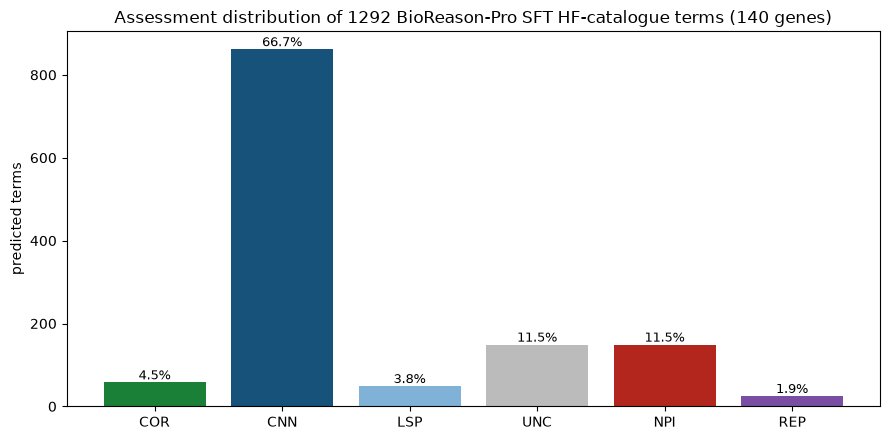

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"COR": "#1a7f37", "CNN": "#16527a", "LSP": "#7fb2d6",
          "UNC": "#bbbbbb", "PLI": "#e0902a", "NPI": "#b3261e", "REP": "#7a4ea3"}
ax.bar(table.index, table["count"], color=[colors.get(a, "#888") for a in table.index])
for i, (a, row) in enumerate(table.iterrows()):
    ax.text(i, row["count"], f"{row['pct']}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("predicted terms")
ax.set_title(f"Assessment distribution of {len(hf)} BioReason-Pro SFT HF-catalogue terms "
             f"({hf[['species', 'gene']].drop_duplicates().shape[0]} genes)")
fig.tight_layout()
outdir = Path("figures"); outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "assessment_distribution.repro.png", dpi=120)
print("saved", outdir / "assessment_distribution.repro.png")
plt.show()

### Interpreting the result

The HF catalogue table is the Table 5 denominator. The web-export rows are useful
for auditing the full 184-gene SFT cohort, but they include the full GO ancestor
hierarchy and should not be pooled with the HF leaf-term subset when reproducing
Table 5 percentages.